
===== CROSS-SESSION REACH-MODULATED HEATMAPS =====
  Session 1: 50 units shown / 78 reach-modulated / 98 total
  Session 2: 50 units shown / 177 reach-modulated / 189 total

Color scale: ±7.0


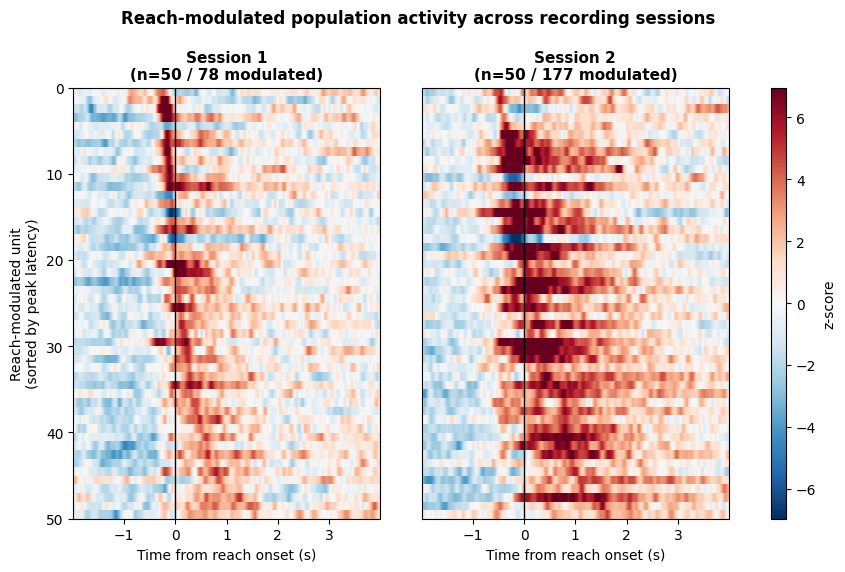


Saved → GRANT_per_session_heatmaps.png/.pdf/.svg

===== DONE =====



In [2]:
# ============================================================
# CROSS-SESSION REACH-MODULATED HEATMAPS (independent pools)
# ============================================================
# For each chosen session: sample N reach-modulated units (random),
# sort by peak latency within that session, plot heatmap.
# Different units per session. No cross-session matching.
# Purpose: "reach-modulated activity is present and structured on every
# recording day" — generic prelim credibility figure.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from pathlib import Path

print("\n===== CROSS-SESSION REACH-MODULATED HEATMAPS =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
SESSION_ANALYSIS_FOLDERS = [
    r"G:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis",
    r"G:\Kevin\2026-03-05_09-27-03\Record Node 101\2026-03-05_09-27-03_experiment2_recording1_analysis",
]
SESSION_LABELS = ["Session 1", "Session 2", "Session 3"]
OUTPUT_FOLDER = r"G:\Kevin\unit_matching"

N_UNITS_PER_SESSION = 50    # target sample size; caps at available count
RANDOM_SEED = 42
REACH_ARRAYS_NAME = "reach_good_in_trial_arrays.npz"   # Cell M-v3 output
# ------------------------------------------------------------

output_folder = Path(OUTPUT_FOLDER)
n_sessions = len(SESSION_ANALYSIS_FOLDERS)
rng = np.random.default_rng(RANDOM_SEED)

# ------------------------------------------------------------
# LOAD PER-SESSION Z-PSTHs FOR REACH-MODULATED UNITS
# ------------------------------------------------------------
session_data = []
for sf, lab in zip(SESSION_ANALYSIS_FOLDERS, SESSION_LABELS):
    af = Path(sf)
    ra_path = af / "qc" / REACH_ARRAYS_NAME
    if not ra_path.exists():
        raise FileNotFoundError(f"{ra_path} not found — run Cell M-v3 first.")
    ra = np.load(ra_path)
    units      = ra["units"]
    z_psth     = ra["z_mean"]
    modulated  = ra["modulated"]
    peak_lat   = None
    if "peak_latency" in ra.files:
        peak_lat = ra["peak_latency"]
    centers    = ra["centers"]

    mod_idx = np.where(modulated)[0]
    n_available = len(mod_idx)
    n_take = min(N_UNITS_PER_SESSION, n_available)
    if n_take < N_UNITS_PER_SESSION:
        print(f"  {lab}: only {n_available} reach-modulated units "
              f"(requested {N_UNITS_PER_SESSION}). Showing all.")
    chosen = rng.choice(mod_idx, size=n_take, replace=False)

    # If peak_latency wasn't stored, compute it on the fly from z_psth within response window
    if peak_lat is None:
        rwin = (-0.5, 2.0)
        resp_mask = (centers >= rwin[0]) & (centers < rwin[1])
        abs_z = np.abs(z_psth[chosen][:, resp_mask])
        peak_idx_in_resp = np.argmax(abs_z, axis=1)
        resp_centers = centers[resp_mask]
        chosen_peak_lat = resp_centers[peak_idx_in_resp]
    else:
        chosen_peak_lat = peak_lat[chosen]

    session_data.append({
        "label": lab,
        "z": z_psth[chosen],
        "peak_lat": chosen_peak_lat,
        "centers": centers,
        "n_units": n_take,
        "n_available": n_available,
        "total_units": len(units),
    })
    print(f"  {lab}: {n_take} units shown / {n_available} reach-modulated "
          f"/ {len(units)} total")

# Shared color scale (98th percentile of |z| across all chosen units, floored)
all_z = np.concatenate([d["z"].ravel() for d in session_data])
vmax = max(np.percentile(np.abs(all_z), 98), 3.0)
print(f"\nColor scale: ±{vmax:.1f}")

# ------------------------------------------------------------
# FIGURE
# ------------------------------------------------------------
fig = plt.figure(figsize=(4.2 * n_sessions + 0.8, 5.6))
gs = GridSpec(1, n_sessions + 1,
              width_ratios=[1] * n_sessions + [0.05], wspace=0.20)

for si, d in enumerate(session_data):
    ax = fig.add_subplot(gs[0, si])
    order = np.argsort(d["peak_lat"])
    sorted_z = d["z"][order]
    im = ax.imshow(sorted_z, aspect="auto",
                   extent=[d["centers"][0], d["centers"][-1],
                           d["n_units"], 0],
                   cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                   interpolation="nearest")
    ax.axvline(0, color="black", lw=1.0)
    ax.set_xlabel("Time from reach onset (s)")
    if si == 0:
        ax.set_ylabel("Reach-modulated unit\n(sorted by peak latency)")
    else:
        ax.set_yticks([])
    ax.set_title(f"{d['label']}\n(n={d['n_units']} / {d['n_available']} modulated)",
                 fontsize=11, fontweight="bold")

cax = fig.add_subplot(gs[0, -1])
plt.colorbar(im, cax=cax, label="z-score")

plt.suptitle("Reach-modulated population activity across recording sessions",
             fontsize=12, fontweight="bold", y=1.02)

out_base = output_folder / "GRANT_per_session_heatmaps"
plt.savefig(f"{out_base}.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig(f"{out_base}.pdf", bbox_inches="tight", facecolor="white")
plt.savefig(f"{out_base}.svg", bbox_inches="tight", facecolor="white")
plt.show()
print(f"\nSaved → {out_base.name}.png/.pdf/.svg")

print("\n===== DONE =====\n")


===== MULTI-SESSION PROBE FOOTPRINT =====
  03-03: 38 good units, 36 modulated (36 exc, 0 sup)
  03-04: 98 good units, 78 modulated (73 exc, 5 sup)
  03-05: 189 good units, 177 modulated (171 exc, 6 sup)
  03-09: 182 good units, 160 modulated (135 exc, 25 sup)
  03-10: 86 good units, 84 modulated (83 exc, 1 sup)

Global max |peak_z|: 20.42 (used to normalize dot sizes)


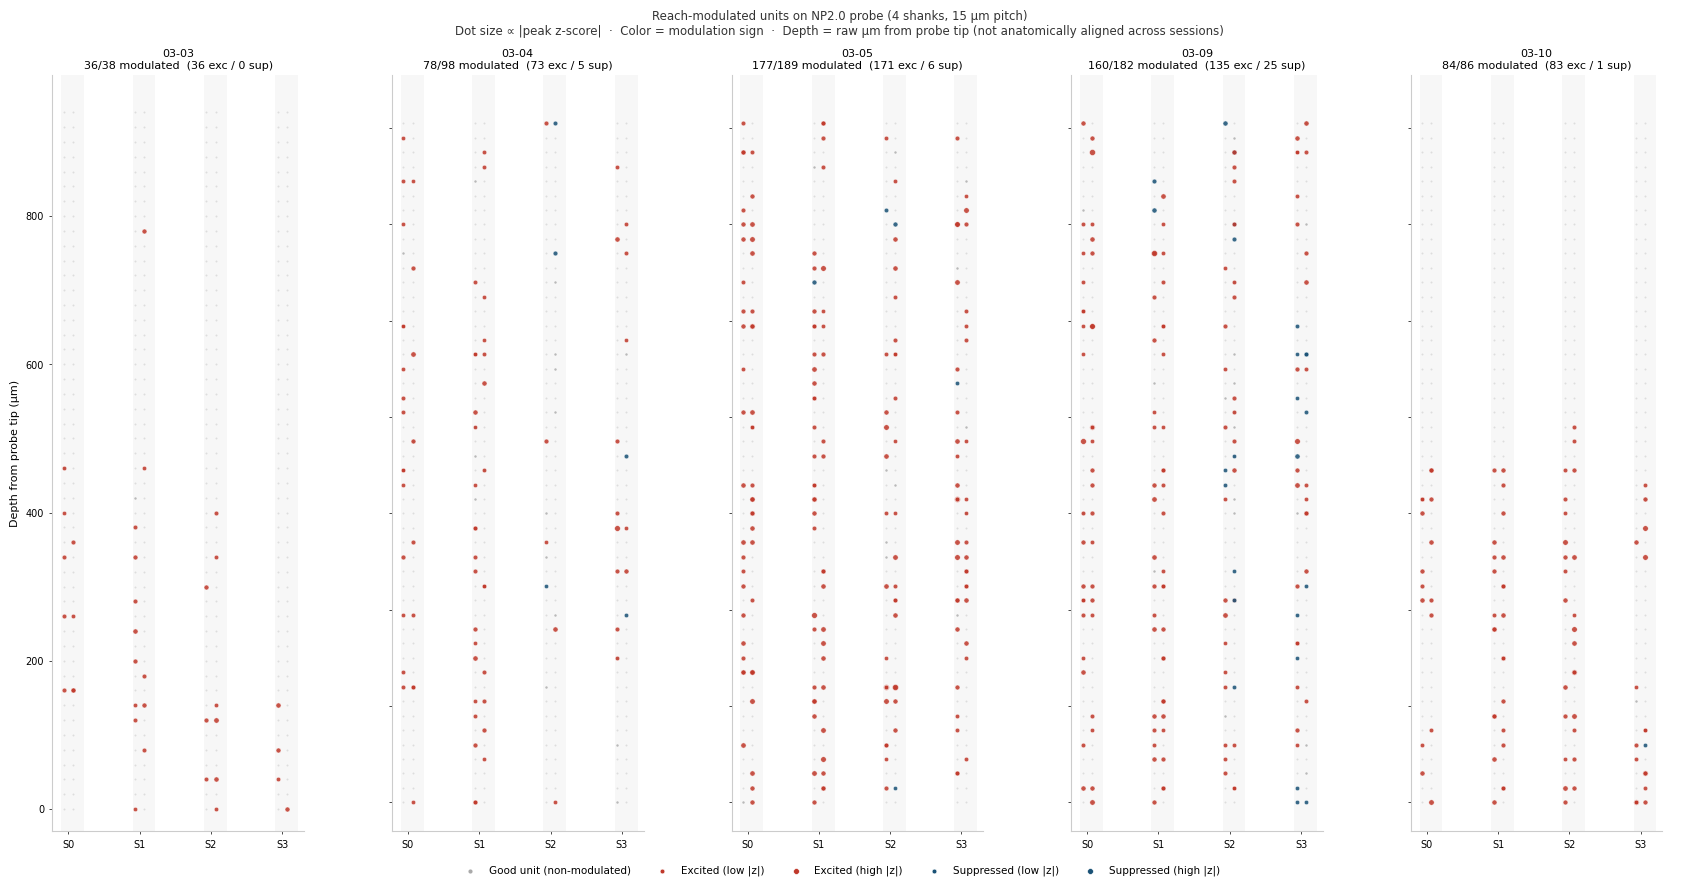


Saved → D:\Kevin\2026-03-03_10-26-01\probe_footprint_reach_modulation.png
Saved → D:\Kevin\2026-03-03_10-26-01\probe_footprint_reach_modulation.pdf

===== DONE =====


In [1]:
# ============================================================
# CELL — MULTI-SESSION PROBE FOOTPRINT: REACH-MODULATED UNITS
# ============================================================
# For each session, plots all 4 shanks of the NP2.0 probe with:
#   - Faint gray dots: all contacts (channel positions)
#   - Tiny dark gray filled circles: non-modulated good units
#     (at their best-channel position)
#   - Colored circles scaled by |peak_z|:
#       Red  = reach-excited modulated units
#       Blue = reach-suppressed modulated units
#
# Unit probe position = best channel of its Kilosort template
# (channel with max peak-to-peak amplitude).
#
# DATA-SHAPING NOTES:
#   - Depth axis is raw µm from probe tip — NOT aligned across
#     sessions anatomically. Sessions had independent insertions
#     so depth values are not directly comparable across columns.
#   - Peak_z used for dot size is from the shuffle-calibrated
#     z-score in the modulation results file, computed over
#     the response window relative to the shuffle null.
#   - NP2.0 shank assignment: channels 0-95 = shank 0,
#     96-191 = shank 1, 192-287 = shank 2, 288-383 = shank 3.
#     Shank X offset = shank_index × 250 µm (manufacturer spec).
#     If channel_positions.npy already encodes absolute X, this
#     is handled automatically — the code checks for this.
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

print("\n===== MULTI-SESSION PROBE FOOTPRINT =====")

# ------------------------------------------------------------
# USER EDIT
# ------------------------------------------------------------
SESSION_FOLDERS = {
    "03-03": r"D:\Kevin\2026-03-03_10-26-01\Record Node 101\2026-03-03_10-26-01_experiment1_recording1_analysis",
    "03-04": r"D:\Kevin\2026-03-04_08-31-33\Record Node 101\2026-03-04_08-31-33_experiment1_recording1_analysis",
    "03-05": r"D:\Kevin\2026-03-05_09-27-03\Record Node 101\2026-03-05_09-27-03_experiment2_recording1_analysis",
    "03-09": r"D:\Kevin\2026-03-09_14-29-25\Record Node 114\2026-03-09_14-29-25_experiment2_recording1_analysis",
    "03-10": r"D:\Kevin\2026-03-10_13-58-34\Record Node 114\2026-03-10_13-58-34_experiment1_recording1_analysis",
}

KILOSORT_FOLDERS = {
    "03-03": r"D:\Kevin\2026-03-03_10-26-01\Record Node 101\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeA\kilosort4",
    "03-04": r"D:\Kevin\2026-03-04_08-31-33\Record Node 101\experiment1\recording1\continuous\Neuropix-PXI-100.ProbeA\kilosort4",
    "03-05": r"D:\Kevin\2026-03-05_09-27-03\Record Node 101\experiment2\recording1\continuous\Neuropix-PXI-100.ProbeA\kilosort4",
    "03-09": r"D:\Kevin\2026-03-09_14-29-25\Record Node 114\experiment2\recording1\continuous\Neuropix-PXI-107.ProbeA\kilosort4",
    "03-10": r"D:\Kevin\2026-03-10_13-58-34\Record Node 114\experiment1\recording1\continuous\Neuropix-PXI-107.ProbeA\kilosort4",
}

MODULATION_ARRAYS_FILE = "reach_good_in_trial_arrays.npz"

# NP2.0 geometry constants
N_CHANNELS_TOTAL = 384
N_PER_SHANK      = 96
N_SHANKS         = 4
SHANK_PITCH_UM   = 250    # µm between shank centres
CONTACT_PITCH_Y  = 15     # µm vertical pitch per shank
CONTACT_COL_X    = [0, 32]  # µm — two columns per shank

# Dot sizing for modulated units: size = BASE_SIZE + SCALE * |peak_z|
DOT_BASE_SIZE   = 8
DOT_SCALE       = 12      # increase for more dramatic size differences
DOT_NONMOD_SIZE = 3       # size for non-modulated good units

# Colors
C_CONTACT   = "#dddddd"   # faint gray — all contacts
C_NONMOD    = "#aaaaaa"   # dark gray — non-modulated good units
C_EXCITED   = "#c0392b"   # red — excited modulated units
C_SUPPRESSED = "#1a5276"  # dark blue — suppressed modulated units
C_SHANK_BG  = "#f7f7f7"   # very faint shank background strip

OUTPUT_PATH = Path(list(SESSION_FOLDERS.values())[0]).parent.parent / \
              "probe_footprint_reach_modulation.png"
# ------------------------------------------------------------

def np2_channel_positions(n_per_shank=96, n_shanks=4,
                           shank_pitch=250, col_x=(0, 32), row_pitch=15):
    """Generate NP2.0 4-shank channel positions as (n_total, 2) array.
    X encodes absolute position across shanks.
    Y encodes depth from probe tip (row 0 = tip)."""
    pos = []
    for s in range(n_shanks):
        x_offset = s * shank_pitch
        for i in range(n_per_shank):
            x = x_offset + col_x[i % 2]
            y = i * row_pitch
            pos.append([x, y])
    return np.array(pos, dtype=float)

def get_unit_probe_positions(ks_folder, good_units, channel_positions, channel_map):
    """For each unit, find its best channel (max template peak-to-peak)
    and return its probe XY position."""
    templates = np.load(ks_folder / "templates.npy")  # (n_templates, n_time, n_ch)
    unit_positions = {}
    unit_best_ch   = {}
    for uid in good_units:
        uid = int(uid)
        if uid >= len(templates):
            continue
        tmpl     = templates[uid]              # (n_time, n_ch)
        best_idx = int(np.argmax(np.ptp(tmpl, axis=0)))  # index into channel_map
        best_ch  = channel_map[best_idx]       # actual channel number
        pos      = channel_positions[best_ch]  # (x, y) in µm
        unit_positions[uid] = pos
        unit_best_ch[uid]   = best_ch
    return unit_positions, unit_best_ch

# ── Verify or generate channel positions ────────────────────
def load_channel_positions(ks_folder):
    """Load channel_positions.npy and verify it looks like NP2.0 4-shank.
    If not (e.g. only 1 shank encoded), regenerate from spec."""
    pos_path = Path(ks_folder) / "channel_positions.npy"
    if pos_path.exists():
        pos = np.load(pos_path)
        x_range = pos[:, 0].max() - pos[:, 0].min()
        if x_range > 200:
            # spans multiple shanks — looks correct
            return pos
        else:
            print(f"  WARNING: channel_positions x_range={x_range:.0f}µm, "
                  f"expected ~750µm for 4-shank NP2.0. Regenerating from spec.")
    else:
        print(f"  channel_positions.npy not found — generating from NP2.0 spec.")
    return np2_channel_positions()

# ── Figure layout ────────────────────────────────────────────
n_sessions = len(SESSION_FOLDERS)

# Each session panel shows all 4 shanks side by side
# Layout: 1 row of session panels, each panel wide enough for 4 shanks
fig_w = 3.5 * n_sessions
fig_h = 9
fig   = plt.figure(figsize=(fig_w, fig_h), facecolor="white")

outer_gs = gridspec.GridSpec(
    1, n_sessions,
    left=0.05, right=0.97,
    top=0.90, bottom=0.06,
    wspace=0.35
)

# Shared color scale for dot sizes — compute max |peak_z| across all sessions
max_peak_z_global = 0.0

all_session_data = {}

for label, folder_str in SESSION_FOLDERS.items():
    folder    = Path(folder_str)
    ks_folder = Path(KILOSORT_FOLDERS[label])

    mod_path = folder / "qc" / MODULATION_ARRAYS_FILE
    if not mod_path.exists():
        print(f"  {label}: modulation file not found — skipping.")
        all_session_data[label] = None
        continue

    modd       = np.load(mod_path)
    good_units = modd["units"]
    modulated  = modd["modulated"]
    peak_z     = modd["peak_z"]
    peak_lat   = modd["peak_latency"]

    max_peak_z_global = max(max_peak_z_global,
                            float(np.abs(peak_z[modulated]).max())
                            if modulated.any() else 0)

    channel_map       = np.load(ks_folder / "channel_map.npy").ravel()
    channel_positions = load_channel_positions(ks_folder)

    unit_positions, unit_best_ch = get_unit_probe_positions(
        ks_folder, good_units, channel_positions, channel_map)

    all_session_data[label] = {
        "good_units":        good_units,
        "modulated":         modulated,
        "peak_z":            peak_z,
        "unit_positions":    unit_positions,
        "channel_positions": channel_positions,
        "channel_map":       channel_map,
        "n_mod":             int(modulated.sum()),
        "n_exc":             int((peak_z[modulated] > 0).sum()) if modulated.any() else 0,
        "n_sup":             int((peak_z[modulated] < 0).sum()) if modulated.any() else 0,
    }
    print(f"  {label}: {len(good_units)} good units, "
          f"{int(modulated.sum())} modulated "
          f"({int((peak_z[modulated] > 0).sum())} exc, "
          f"{int((peak_z[modulated] < 0).sum())} sup)")

print(f"\nGlobal max |peak_z|: {max_peak_z_global:.2f} "
      f"(used to normalize dot sizes)")

# ── Draw each session panel ──────────────────────────────────
for col_i, (label, folder_str) in enumerate(SESSION_FOLDERS.items()):
    sd = all_session_data.get(label)
    ax = fig.add_subplot(outer_gs[col_i])

    if sd is None:
        ax.text(0.5, 0.5, "No data", ha="center", va="center",
                transform=ax.transAxes, fontsize=9, color="gray")
        ax.set_title(label, fontsize=9)
        ax.axis("off")
        continue

    ch_pos    = sd["channel_positions"]
    good_units = sd["good_units"]
    modulated  = sd["modulated"]
    peak_z     = sd["peak_z"]
    unit_pos   = sd["unit_positions"]

    # ── Draw all contacts as faint dots ─────────────────────
    # Draw shank background strips first
    for s in range(N_SHANKS):
        x_ctr = s * SHANK_PITCH_UM + np.mean(CONTACT_COL_X)
        ax.axvspan(x_ctr - 25, x_ctr + 55,
                   facecolor=C_SHANK_BG, edgecolor="none", zorder=0)

    ax.scatter(ch_pos[:, 0], ch_pos[:, 1],
               s=2, color=C_CONTACT, zorder=1, linewidths=0)

    # ── Plot non-modulated good units ────────────────────────
    for u_i, uid in enumerate(good_units):
        if modulated[u_i]:
            continue
        uid = int(uid)
        if uid not in unit_pos:
            continue
        x, y = unit_pos[uid]
        ax.scatter(x, y, s=DOT_NONMOD_SIZE, color=C_NONMOD,
                   zorder=2, linewidths=0, alpha=0.7)

    # ── Plot modulated units (sized by |peak_z|) ─────────────
    for u_i, uid in enumerate(good_units):
        if not modulated[u_i]:
            continue
        uid = int(uid)
        if uid not in unit_pos:
            continue
        x, y   = unit_pos[uid]
        pz      = float(peak_z[u_i])
        abs_pz  = abs(pz)
        # Normalize to global max for consistent sizing across sessions
        norm_pz = abs_pz / max(max_peak_z_global, 1.0)
        dot_s   = DOT_BASE_SIZE + DOT_SCALE * norm_pz
        color   = C_EXCITED if pz > 0 else C_SUPPRESSED
        ax.scatter(x, y, s=dot_s, color=color, zorder=4,
                   linewidths=0.4, edgecolors="white", alpha=0.85)

    # ── Axes formatting ──────────────────────────────────────
    y_min = ch_pos[:, 1].min()
    y_max = ch_pos[:, 1].max()
    x_min = ch_pos[:, 0].min()
    x_max = ch_pos[:, 0].max()

    ax.set_xlim(x_min - 40, x_max + 60)
    ax.set_ylim(y_min - 30, y_max + 50)

    # X ticks: one per shank at the shank center
    shank_centers = [s * SHANK_PITCH_UM + np.mean(CONTACT_COL_X)
                     for s in range(N_SHANKS)]
    ax.set_xticks(shank_centers)
    ax.set_xticklabels([f"S{s}" for s in range(N_SHANKS)],
                       fontsize=7)

    if col_i == 0:
        ax.set_ylabel("Depth from probe tip (µm)", fontsize=8)
    else:
        ax.set_yticklabels([])

    ax.set_title(f"{label}\n"
                 f"{sd['n_mod']}/{len(good_units)} modulated  "
                 f"({sd['n_exc']} exc / {sd['n_sup']} sup)",
                 fontsize=8, pad=5)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#cccccc")
    ax.spines["bottom"].set_color("#cccccc")
    ax.tick_params(colors="black", labelsize=7, length=2.5, width=0.5)

# ── Legend ───────────────────────────────────────────────────
legend_ax = fig.add_axes([0.97, 0.55, 0.01, 0.01])  # invisible anchor
legend_ax.axis("off")

legend_elements = [
    plt.scatter([], [], s=DOT_NONMOD_SIZE * 3, color=C_NONMOD,
                label="Good unit (non-modulated)", linewidths=0),
    plt.scatter([], [], s=DOT_BASE_SIZE + DOT_SCALE * 0.3,
                color=C_EXCITED, label="Excited (low |z|)",
                edgecolors="white", linewidths=0.4),
    plt.scatter([], [], s=DOT_BASE_SIZE + DOT_SCALE * 0.8,
                color=C_EXCITED, label="Excited (high |z|)",
                edgecolors="white", linewidths=0.4),
    plt.scatter([], [], s=DOT_BASE_SIZE + DOT_SCALE * 0.3,
                color=C_SUPPRESSED, label="Suppressed (low |z|)",
                edgecolors="white", linewidths=0.4),
    plt.scatter([], [], s=DOT_BASE_SIZE + DOT_SCALE * 0.8,
                color=C_SUPPRESSED, label="Suppressed (high |z|)",
                edgecolors="white", linewidths=0.4),
]

fig.legend(handles=legend_elements,
           loc="lower center", ncol=5,
           fontsize=7.5, frameon=False,
           bbox_to_anchor=(0.5, 0.0))

fig.text(0.5, 0.945,
         "Reach-modulated units on NP2.0 probe (4 shanks, 15 µm pitch)\n"
         "Dot size ∝ |peak z-score|  ·  Color = modulation sign  ·  "
         "Depth = raw µm from probe tip (not anatomically aligned across sessions)",
         ha="center", fontsize=8.5, color="#333333")

# ── Save ─────────────────────────────────────────────────────
out_dir = Path(list(SESSION_FOLDERS.values())[0]).parent.parent
out_png = out_dir / "probe_footprint_reach_modulation.png"
out_pdf = out_dir / "probe_footprint_reach_modulation.pdf"
out_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(out_png, dpi=250, bbox_inches="tight", facecolor="white")
plt.savefig(out_pdf, bbox_inches="tight", facecolor="white")
plt.show()

print(f"\nSaved → {out_png}")
print(f"Saved → {out_pdf}")
print("\n===== DONE =====")